In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data = {
    'CGPA': [7.5, 8.2, 6.9, 9.1, 5.8, 7.2, 8.8, 6.5, 9.5, 7.8],
    'IQ': [110, 120, 95, 130, 85, 105, 125, 100, 140, 115],
    'Profile_Score': [7, 8, 6, 9, 5, 7, 8, 6, 9, 7],
    'Placed': [1, 1, 0, 1, 0, 1, 1, 0, 1, 1]
}

df = pd.DataFrame(data)
df

,CGPA,IQ,Profile_Score,Placed
0,7.5,110,7,1
1,8.2,120,8,1
2,6.9,95,6,0
3,9.1,130,9,1
4,5.8,85,5,0
5,7.2,105,7,1
6,8.8,125,8,1
7,6.5,100,6,0
8,9.5,140,9,1
9,7.8,115,7,1


In [4]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CGPA           10 non-null     float64
 1   IQ             10 non-null     int64  
 2   Profile_Score  10 non-null     int64  
 3   Placed         10 non-null     int64  
dtypes: float64(1), int64(3)
memory usage: 452.0 bytes


,CGPA,IQ,Profile_Score,Placed
count,10.000000,10.000000,10.000000,10.000000
mean,7.730000,112.500000,7.200000,0.700000
std,1.185139,16.873714,1.316561,0.483046
min,5.800000,85.000000,5.000000,0.000000
25%,6.975000,101.250000,6.250000,0.250000
50%,7.650000,112.500000,7.000000,1.000000
75%,8.650000,123.750000,8.000000,1.000000
max,9.500000,140.000000,9.000000,1.000000


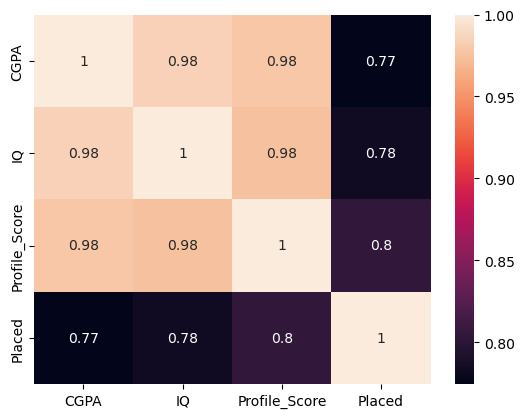

In [5]:
sns.heatmap(df.corr(), annot=True)
plt.show()

In [6]:
X = df[['CGPA', 'IQ', 'Profile_Score']]
y = df['Placed']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [9]:
y_pred = model.predict(X_test)
y_pred

array([1, 1])

In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=[0,1])
print(cm)

[[0 0]
 [0 2]]


In [24]:
new_student = pd.DataFrame({
    'CGPA': [7],
    'IQ': [120],
    'Profile_Score': [8]
})

prediction = model.predict(new_student)

print("Prediction:", "PLACED 🎉" if prediction[0] == 1 else "NOT PLACED")")

Prediction: PLACED 🎉


In [17]:
import joblib

joblib.dump(model, "placement_model.pkl")

['placement_model.pkl']

In [18]:
loaded_model = joblib.load("placement_model.pkl")